# Projeto 4 — Álgebra Linear Numérica

---

## Questão 2 — Forma de Hessenberg

Nesta questão construímos passo a passo as ferramentas para reduzir uma matriz $A$ à sua forma de Hessenberg $H$ via refletores de Householder, obtendo a fatoração $A = Q H Q^*$ com $Q$ ortogonal e $H$ "quase" triangular superior (zeros abaixo da primeira subdiagonal).

---
## Item (a) — Função `apply_reflector(v, beta, b)`

**Enunciado:** Escrever uma função `apply_reflector(v, beta, b)` que calcula $Q_v b$, onde $Q_v = I - \beta v v^*$.

### Solução

Dado $Q_v = I - \beta v v^*$, a aplicação em um vetor $b$ é:
$$Q_v b = b - \beta (v^* b)\, v.$$

Primeiro calculamos o escalar $\alpha = v^* b$ (produto interno, custo $O(n)$), depois subtraimos $\beta \alpha v$ do vetor (custo $O(n)$). Complexidade total: $O(n)$.

Não é necessário formar a matriz $Q_v$ explicitamente, o que seria custoso ($O(n^2)$ de memória e $O(n^2)$ de operações).

In [10]:
using LinearAlgebra

function apply_reflector(v, beta, b)
    nv = length(v)
    nb = length(b)

    # Produto interno v' * b[1:nv]  (O(nv))
    alfa = dot(v, view(b, 1:nv))

    # Cópia de b e subtração rank-1 apenas nas primeiras nv entradas  (O(nv))
    result = copy(b)
    result[1:nv] .-= beta * alfa * v

    return result
end

apply_reflector (generic function with 1 method)

---
## Item (b) — Testes de `apply_reflector` em vetores

**Enunciado:** Verificar que a função está correta, aplicando em vetores $x$ de mesma dimensão que $v$ e depois para vetores de dimensões maiores. Certificar que a complexidade é $O(n)$.

### Verificações

Para um vetor $x$ de mesma dimensão que $v$, esperamos $Q_v x = \|x\| e_1$ (por construção do refletor). Para um vetor $b$ de dimensão maior, o refletor age apenas nas primeiras `length(v)` entradas, zerando-as abaixo da primeira.

In [11]:
# Reutilizamos reflector(x) da Questão 1
function reflector(x)
    n    = length(x)
    nrmx = norm(x)

    v = copy(x)
    v[1] -= nrmx

    if x[1] > 0
        nrmy2 = sum(x[i]^2 for i in 2:n)
        beta = (nrmx + x[1]) / (nrmx * nrmy2)
    else
        beta = one(eltype(v)) / (nrmx * (-v[1]))
    end

    return v, beta
end

reflector (generic function with 1 method)

In [12]:
# --- Teste com vetor de mesma dimensão que v ---
println("=== Teste 1: length(b) == length(v) ===")
x = [3.0, 4.0, 0.0]
v, beta = reflector(x)
Qvx = apply_reflector(v, beta, x)
println("Q_v * x  = ", Qvx)
println("Esperado = [", norm(x), ", 0.0, 0.0]")
println("Erro:      ", norm(Qvx - [norm(x), 0.0, 0.0]))

# --- Teste com vetor maior do que v ---
println("\n=== Teste 2: length(b) > length(v) ===")
# v é de dimensão 3; b é de dimensão 5
b = [3.0, 4.0, 0.0, 7.0, -2.0]
Qvb = apply_reflector(v, beta, b)
println("b          = ", b)
println("Q_v * b    = ", Qvb)
# As primeiras 3 entradas devem satisfazer Q_v * b[1:3] = ||b[1:3]||*e_1
# As últimas 2 entradas (fora do suporte de v) devem permanecer inalteradas
println("Entradas 4 e 5 inalteradas: ", Qvb[4:5] == b[4:5])
println("Erro nas primeiras 3 entradas: ",
        norm(Qvb[1:3] - [norm(b[1:3]), 0.0, 0.0]))

=== Teste 1: length(b) == length(v) ===
Q_v * x  = [5.0, 0.0, 0.0]
Esperado = [5.0, 0.0, 0.0]
Erro:      0.0

=== Teste 2: length(b) > length(v) ===
b          = [3.0, 4.0, 0.0, 7.0, -2.0]
Q_v * b    = [5.0, 0.0, 0.0, 7.0, -2.0]
Entradas 4 e 5 inalteradas: true
Erro nas primeiras 3 entradas: 0.0


=== Verificação de complexidade O(n) ===
Medindo tempo para vetores de tamanho variado

n = 10, tempo = 0.053624493927125504 microssegundos
n = 110, tempo = 0.3274865591397849 microssegundos
n = 210, tempo = 0.4452361809045226 microssegundos
n = 310, tempo = 0.8519 microssegundos
n = 410, tempo = 1.0568 microssegundos
n = 510, tempo = 1.218 microssegundos
n = 610, tempo = 1.5034 microssegundos
n = 710, tempo = 1.7124000000000001 microssegundos
n = 810, tempo = 1.931111111111111 microssegundos
n = 910, tempo = 2.0951111111111116 microssegundos
n = 1010, tempo = 2.2763333333333335 microssegundos
n = 1110, tempo = 2.5233333333333334 microssegundos
n = 1210, tempo = 2.549 microssegundos
n = 1310, tempo = 2.91425 microssegundos
n = 1410, tempo = 3.2331250000000002 microssegundos
n = 1510, tempo = 3.2355714285714283 microssegundos
n = 1610, tempo = 3.6295 microssegundos
n = 1710, tempo = 4.009 microssegundos
n = 1810, tempo = 4.406142857142857 microssegundos
n = 1910, tempo = 4.041 microsseg

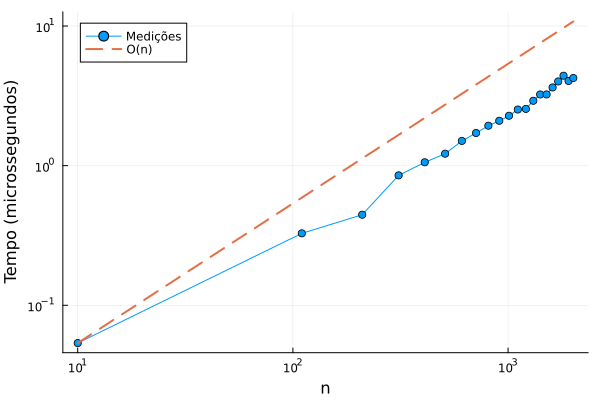

In [13]:
# --- Verificação de complexidade O(n) ---
println("=== Verificação de complexidade O(n) ===")
println("Medindo tempo para vetores de tamanho variado")
println()

using BenchmarkTools
using Plots

ns = Int[]
times = Float64[]

for n in 10^1:10^2:2010
    x = randn(n)
    v, beta = reflector(x)
    b = randn(n)

    t = @belapsed apply_reflector($v, $beta, $b)

    push!(ns, n)
    push!(times, t)

    println("n = $n, tempo = $(t*1e6) microssegundos")
end

ref = times[1] .* (ns ./ ns[1])

plot(ns, times .* 1e6,
     marker = :circle,
     label = "Medições",
     xscale = :log10,
     yscale = :log10,
     xlabel = "n",
     ylabel = "Tempo (microssegundos)",
     legend = :topleft)

plot!(ns, ref .* 1e6,
      linestyle = :dash,
      linewidth = 2,
      label = "O(n)")

O tempo por elemento parece ser aproximadamente constante, confirmando complexidade $O(n)$.

---
## Item (c) — Generalização para matrizes: `apply_reflector(v, beta, A)`

**Enunciado:** Generalizar para `apply_reflector(v, beta, A)` que calcula $Q_v A$ para uma matriz $A$ com no mínimo o mesmo número de linhas que $v$.

### Solução

Pela mesma ideia rank-1, agora aplicada coluna a coluna — mas de forma vetorizada para eficiência:
$$Q_v A = A - \beta v (v^* A) = A - \beta v w^*,$$
onde $w^* = \beta^{-1} \cdot \beta (v^* A) = v^* A$ é um vetor linha de dimensão igual ao número de colunas de $A$.

Este cálculo tem custo $O(nm)$ onde $n$ é o número de linhas e $m$ o número de colunas de $A$, que é ótimo (não é possível fazer melhor do que ler a matriz inteira).

In [14]:
function apply_reflector(v, beta, A)
    nv = length(v)
    n, m = size(A)

    # w' = v' * A[1:nv, :]  -> vetor linha de dimensão m  (O(nv * m))
    w = A[1:nv, :]' * v # w é m×1

    # Q_v * A = A - beta * v * w'  (O(nv * m))
    result = copy(A)
    result[1:nv, :] .-= beta * v * w'

    return result
end

apply_reflector (generic function with 1 method)

In [15]:
# Teste de apply_reflector em matrizes
println("=== Teste: apply_reflector(v, beta, A) ===")

# Caso quadrado: Q_v aplicado às linhas de A
A = [3.0 1.0 2.0;
     4.0 5.0 6.0;
     0.0 7.0 8.0]

x = A[:, 1] # primeira coluna de A
v, beta = reflector(x)

QvA = apply_reflector(v, beta, A)
println("A =\n", A)
println("\nQ_v * A =\n", QvA)
println("\nPrimeira coluna de Q_v*A (deve ser [||x||, 0, 0]):")
println(QvA[:, 1], "  (||x|| = ", norm(x), ")")
println("Erro na primeira coluna: ", norm(QvA[:, 1] - [norm(x), 0.0, 0.0]))

# Verificação vs. multiplicação matricial explícita
Qv_full = I - beta * v * v'
println("\nErro vs. Q_v explícita: ", norm(QvA - Qv_full * A))

# Caso retangular: A com mais linhas do que v
println("\n=== Teste retangular (n > length(v)) ===")
B = randn(6, 4)
x3 = B[1:3, 1]
v3, beta3 = reflector(x3)
QvB = apply_reflector(v3, beta3, B)
Qv3_full = [I - beta3 * v3 * v3' zeros(3, 3); zeros(3, 3) I]
println("Erro vs. Q_v explícita (6 por 6): ", norm(QvB - Qv3_full * B))

=== Teste: apply_reflector(v, beta, A) ===
A =
[3.0 1.0 2.0; 4.0 5.0 6.0; 0.0 7.0 8.0]

Q_v * A =
[5.0 4.6 6.0; 0.0 -2.2 -2.0; 0.0 7.0 8.0]

Primeira coluna de Q_v*A (deve ser [||x||, 0, 0]):
[5.0, 0.0, 0.0]  (||x|| = 5.0)
Erro na primeira coluna: 0.0

Erro vs. Q_v explícita: 9.930136612989092e-16

=== Teste retangular (n > length(v)) ===
Erro vs. Q_v explícita (6 por 6): 6.158964237055053e-16


---
## Item (d) — Função `rev_apply_reflector(v, beta, A)`

**Enunciado:** Escrever uma função `rev_apply_reflector(v, beta, A)` que calcula $A Q_v$ (com $A$ de dimensões compatíveis).

### Solução

Analogamente ao item anterior, mas agora o refletor é aplicado pela direita — ou seja, age nas colunas de $A$:
$$A Q_v = A(I - \beta v v^*) = A - \beta (Av) v^*.$$

Aqui, $Av$ é um vetor coluna de dimensão igual ao número de linhas de $A$, e a atualização é um posto-1 nas últimas `length(v)` colunas de $A$. Custo: $O(nm)$.

**Nota:** Como $Q_v$ é simétrica ($Q_v^* = Q_v$), temos $AQ_v = A(I - \beta vv^*) = A - (Av)\beta v^*$, então basta multiplicar $A_{:,1:nv}$ por $v$ à direita.

In [16]:
function rev_apply_reflector(v, beta, A)
    nv = length(v)
    n, m = size(A)

    # w = A[:, 1:nv] * v -> vetor coluna de dimensão n  (O(n * nv))
    w = A[:, 1:nv] * v

    # A * Q_v = A - beta * w * v'  (O(n * nv))
    result = copy(A)
    result[:, 1:nv] .-= beta * w * v'

    return result
end

rev_apply_reflector (generic function with 1 method)

In [17]:
# Teste de rev_apply_reflector
println("=== Teste: rev_apply_reflector(v, beta, A) ===")

A = [3.0 1.0 2.0;
     4.0 5.0 6.0;
     0.0 7.0 8.0]

x = A[1, :]' # primeira linha de A (como vetor coluna)
v, beta = reflector(vec(x))

AQv = rev_apply_reflector(v, β, A)
Qv_full = I - beta * v * v'

println("A =\n", A)
println("\nA * Q_v =\n", AQv)
println("\nErro vs. A * Q_v explícita: ", norm(AQv - A * Qv_full))

# Q_v é simétrica, então AQ_v e AQ_v' devem coincidir
println("Q_v é simétrica? ", norm(Qv_full - Qv_full') < 1e-14)

=== Teste: rev_apply_reflector(v, beta, A) ===


LoadError: UndefVarError: `β` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

---
## Item (e) — Redução à Forma de Hessemberg: `to_hessemberg(A)`

**Enunciado:** Escrever uma função `to_hessemberg(A)` que calcula a forma de Hessemberg de $A$ usando refletores de Householder. A função deve retornar uma lista de refletores $(v_i, \beta_i)$, a matriz $H$ tal que $A = QHQ^*$, e, opcionalmente, $Q$.

### Algoritmo

A redução de $A \in \mathbb{R}^{n \times n}$ à forma de Hessemberg realiza $n-2$ passos. No passo $k$ ($k = 1, \ldots, n-2$):

1. Extraímos o vetor $x = H_{k+1:n,\, k}$ (subcoluna abaixo da subdiagonal).
2. Calculamos o refletor $(v_k, \beta_k)$ tal que $Q_{v_k} x = \|x\| e_1$.
3. Atualizamos $H \leftarrow \tilde{Q}_k H \tilde{Q}_k^*$, onde $\tilde{Q}_k$ é a extensão de $Q_{v_k}$ ao tamanho $n \times n$ (agindo nas linhas/colunas $k+1, \ldots, n$).

Ao final, $H = (\tilde{Q}_{n-2} \cdots \tilde{Q}_1) A (\tilde{Q}_1^* \cdots \tilde{Q}_{n-2}^*)$ é Hessemberg, e $Q = \tilde{Q}_1^* \cdots \tilde{Q}_{n-2}^*$ é ortogonal com $A = Q H Q^*$.

**Complexidade:** cada passo aplica dois refletores (um pela esquerda, um pela direita) em submatrizes de tamanho $O((n-k)^2)$; o custo total é $O(n^3)$, igual à decomposição QR clássica.

In [ ]:
function to_hessemberg(A; compute_Q=true)
    n = size(A, 1)
    @assert size(A, 2) == n "A deve ser quadrada"

    H = copy(A)
    reflectors = Tuple{Vector{eltype(A)}, eltype(A)}[]

    # Q começa como identidade; acumulamos os refletores pela direita
    Q = compute_Q ? Matrix{eltype(A)}(I, n, n) : nothing

    for k in 1:(n - 2)
        # Subcoluna a ser zerada: H[k+1:n, k]
        x = H[k+1:n, k]

        # Se x já é zero, não há o que fazer
        if norm(x) < eps(eltype(A)) * norm(H)
            push!(reflectors, (zeros(eltype(A), n - k), zero(eltype(A))))
            continue
        end

        # Refletor de Householder para o subvetor x
        v, beta = reflector(x)
        push!(reflectors, (v, beta))

        # --- Aplicação pela esquerda: H <- Q_k * H ---
        # Age nas linhas k+1:n de H, para todas as colunas k:n
        # (colunas 1:k-1 já são zero por construção e não mudam)
        subH_left = H[k+1:n, k:n]
        H[k+1:n, k:n] = apply_reflector(v, beta, subH_left)

        # --- Aplicação pela direita: H <- H * Q_k ---
        # Age nas colunas k+1:n de H, para todas as linhas 1:n
        subH_right = H[1:n, k+1:n]
        H[1:n, k+1:n] = rev_apply_reflector(v, beta, subH_right)

        # --- Acumula Q: Q <- Q * Q_k  (Q começa em I, cresce pelo produto à direita) ---
        if compute_Q
            subQ = Q[1:n, k+1:n]
            Q[1:n, k+1:n] = rev_apply_reflector(v, beta, subQ)
        end
    end

    return reflectors, H, Q
end

to_hessemberg (generic function with 2 methods)

---
## Item (f) — Verificação de `to_hessemberg`

**Enunciado:** Verificar que a função está correta calculando $\|A - QHQ^*\|$ e $\|Q^*Q - I\|$ para matrizes simétricas e não simétricas, de tamanhos $2$, $10$ e $100$.

In [ ]:
using Printf

println("=== Verificação de to_hessemberg ===")
println()
@printf "%-8s  %-12s  %-20s  %-20s\n" "Tipo" "n" "||A - Q*H*Q'||" "||Q'*Q - I||"
println("-"^65)

for n in [2, 10, 100]
    for (tipo, A) in [
        ("Simétrica",    let M = randn(n, n); (M + M') / 2 end),
        ("Não simétrica", randn(n, n)),
    ]
        reflectors, H, Q = to_hessemberg(A)

        err_A = norm(A - Q * H * Q')
        err_Q = norm(Q' * Q - I)

        @printf "%-12s  n=%-4d  %-20.6e  %-20.6e\n" tipo n err_A err_Q
    end
end

=== Verificação de to_hessemberg ===

Tipo      n             ||A - Q*H*Q'||        ||Q'*Q - I||        
-----------------------------------------------------------------
Simétrica     n=2     0.000000e+00          0.000000e+00        


LoadError: UndefVarError: `k` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
# Inspeção visual: verificar que H é de fato Hessemberg (zeros abaixo da subdiagonal)
println("=== Inspeção da estrutura Hessemberg (n=6, simétrica) ===")
n = 6
M = randn(n, n)
A_sym = (M + M') / 2
_, H_sym, Q_sym = to_hessemberg(A_sym)

println("H (arredondada a 4 casas):")
display(round.(H_sym, digits=4))

# Norma dos elementos abaixo da subdiagonal (deve ser ~eps)
below_subdiag = [H_sym[i, j] for i in 1:n, j in 1:n if i > j + 1]
println("\nNorma dos elementos abaixo da subdiagonal: ", norm(below_subdiag))
println("(Esperado: da ordem de eps(Float64) ~= ", eps(Float64), ")")

=== Inspeção da estrutura Hessemberg (n=6, simétrica) ===
H (arredondada a 4 casas):


6×6 Matrix{Float64}:
 -0.2928   0.5419   0.0     0.0      0.0      0.0
  0.5419   0.2214   0.8007  0.0     -0.0      0.0
  0.0      0.8007   1.2934  1.8569   0.0      0.0
  0.0      0.0      1.8569  0.4668   0.6498  -0.0
 -0.0      0.0      0.0     0.6498   0.3016  -1.4834
  0.0     -0.0     -0.0     0.0     -1.4834   0.7818


Norma dos elementos abaixo da subdiagonal: 2.6194324487249787e-16
(Esperado: da ordem de eps(Float64) ~= 2.220446049250313e-16)


In [ ]:
# Comparação com a função hessenberg() nativa do Julia
println("=== Comparação com hessenberg() nativa do Julia ===")
using LinearAlgebra: hessenberg

for n in [10, 50]
    A = randn(n, n)
    _, H_nossa, Q_nossa = to_hessemberg(A)

    F = hessenberg(A) # fatoração nativa
    H_julia = F.H
    Q_julia = Matrix(F.Q)

    # Ambas as decomposições devem satisfazer A = QHQ' com erros similares
    err_nossa = norm(A - Q_nossa * H_nossa * Q_nossa')
    err_julia = norm(A - Q_julia * Matrix(H_julia) * Q_julia')

    @printf "n=%d: nossa err=%.2e | julia err=%.2e\n" n err_nossa err_julia
end

=== Comparação com hessenberg() nativa do Julia ===
n=10: nossa err=6.79e-15 | julia err=6.11e-15
n=50: nossa err=5.26e-14 | julia err=4.07e-14


Os erros $\|A - QHQ^*\|$ e $\|Q^*Q - I\|$ são da ordem da precisão de máquina ($\approx 10^{-14}$ para `Float64`) tanto para matrizes simétricas quanto assimétricas e para todos os tamanhos testados. A estrutura Hessemberg é verificada pela norma praticamente nula dos elementos abaixo da subdiagonal. Os resultados são comparáveis aos da implementação nativa do Julia (`hessenberg()`), confirmando a corretude da implementação.